In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer

### Importing Data

In [2]:
disaster_df = pd.read_csv('datasets/global_climate_events_economic_impact_2020_2025.csv')
indicators_df_full = pd.read_csv('datasets/world_bank_data_2025.csv')
demographic_df = pd.read_csv('datasets/demographic_data_2020_2025.csv', header=1)

### Data Filtering

In [3]:
# Convert indicator and demographic names to disaster names
country_name_map_to_disaster = {
    
    # indicators/demographics to disaster
    'Czechia': 'Czech Republic',
    'Egypt, Arab Rep.': 'Egypt',
    'Russian Federation': 'Russia',
    'Korea, Rep.': 'South Korea',
    'Turkiye': 'Turkey',
    'United Arab Emirates': 'UAE',
    'Viet Nam': 'Vietnam',

    # demographic special cases
    'Korea, South': 'South Korea'
}

# Standardize indicator dataset
indicators_df_full['country_name'] = indicators_df_full['country_name'].replace(country_name_map_to_disaster)

# Standardize demographic dataset
demographic_df['Name'] = demographic_df['Name'].replace(country_name_map_to_disaster)

# Disaster countries (countries we want)
disaster_countries = set(disaster_df['country'].unique())

# Filter indicators
indicators_df = indicators_df_full[indicators_df_full['country_name'].isin(disaster_countries)]

# Filter demographics
demographic_df = demographic_df[demographic_df['Name'].isin(disaster_countries)]

In [4]:
indicator_countries = set(indicators_df['country_name'].unique())
demographic_countries = set(demographic_df['Name'].unique())

print("Countries in disaster but not in indicators:")
print(disaster_countries - indicator_countries)

print("\nCountries in disaster but not in demographics:")
print(disaster_countries - demographic_countries)

print("\nCountries in indicators but not in demographics:")
print(indicator_countries - demographic_countries)

print("\nCountries in demographics but not in indicators:")
print(demographic_countries - indicator_countries)


Countries in disaster but not in indicators:
set()

Countries in disaster but not in demographics:
set()

Countries in indicators but not in demographics:
set()

Countries in demographics but not in indicators:
set()


### Data Cleaning and Preprocessing

In [5]:
# ---- Disaster Dataset Cleaning ---- #

# drop useless columns in disaster dataframe
disaster_df = disaster_df.drop(columns=['event_id'])

# datetime conversion
disaster_df['date'] = pd.to_datetime(disaster_df['date'])

# encoding

In [6]:
# ---- Indicators Dataset Cleaning ---- #

# drop useless columns in indicators dataframe
indicators_df = indicators_df.drop(columns=['country_id'])

# standarize monetary columns to million USD
indicators_df.loc[:, 'GDP (Current USD)'] = indicators_df['GDP (Current USD)'] / 1e6
#indicators_df.loc[:, 'GDP per Capita (Current USD)'] = indicators_df['GDP per Capita (Current USD)'] / 1e6
indicators_df.loc[:, 'Gross National Income (USD)'] = indicators_df['Gross National Income (USD)'] / 1e6

# rename standarized columns
indicators_df.rename(columns={
    'GDP (Current USD)': 'GDP (Million USD)',
    'Gross National Income (USD)': 'Gross National Income (Million USD)'
}, inplace=True)

# encoding

In [7]:
# ---- Demographic Dataset Cleaning ---- #

# drop useless columns in demographics dataframe
demographic_df = demographic_df.drop(columns=['GENC'])

# remove separation formatting
def is_year_separator(row):
    return any(str(cell).strip().startswith('->') for cell in row)
demographic_df = demographic_df[~demographic_df.apply(is_year_separator, axis=1)].reset_index(drop=True)

# replace missing value syntax '--' with NaN
demographic_df = demographic_df.replace('--', np.nan)

# convert columns to numeric type
for col in demographic_df.columns:
    if col != 'Name':
        # remove commas and convert to numeric
        demographic_df[col] = (
            demographic_df[col]
            .astype(str)           # ensure string type first
            .str.replace(",", "")  # remove commas
        )
        demographic_df[col] = pd.to_numeric(demographic_df[col], errors='coerce')

# encoding

#### Missingness Analysis

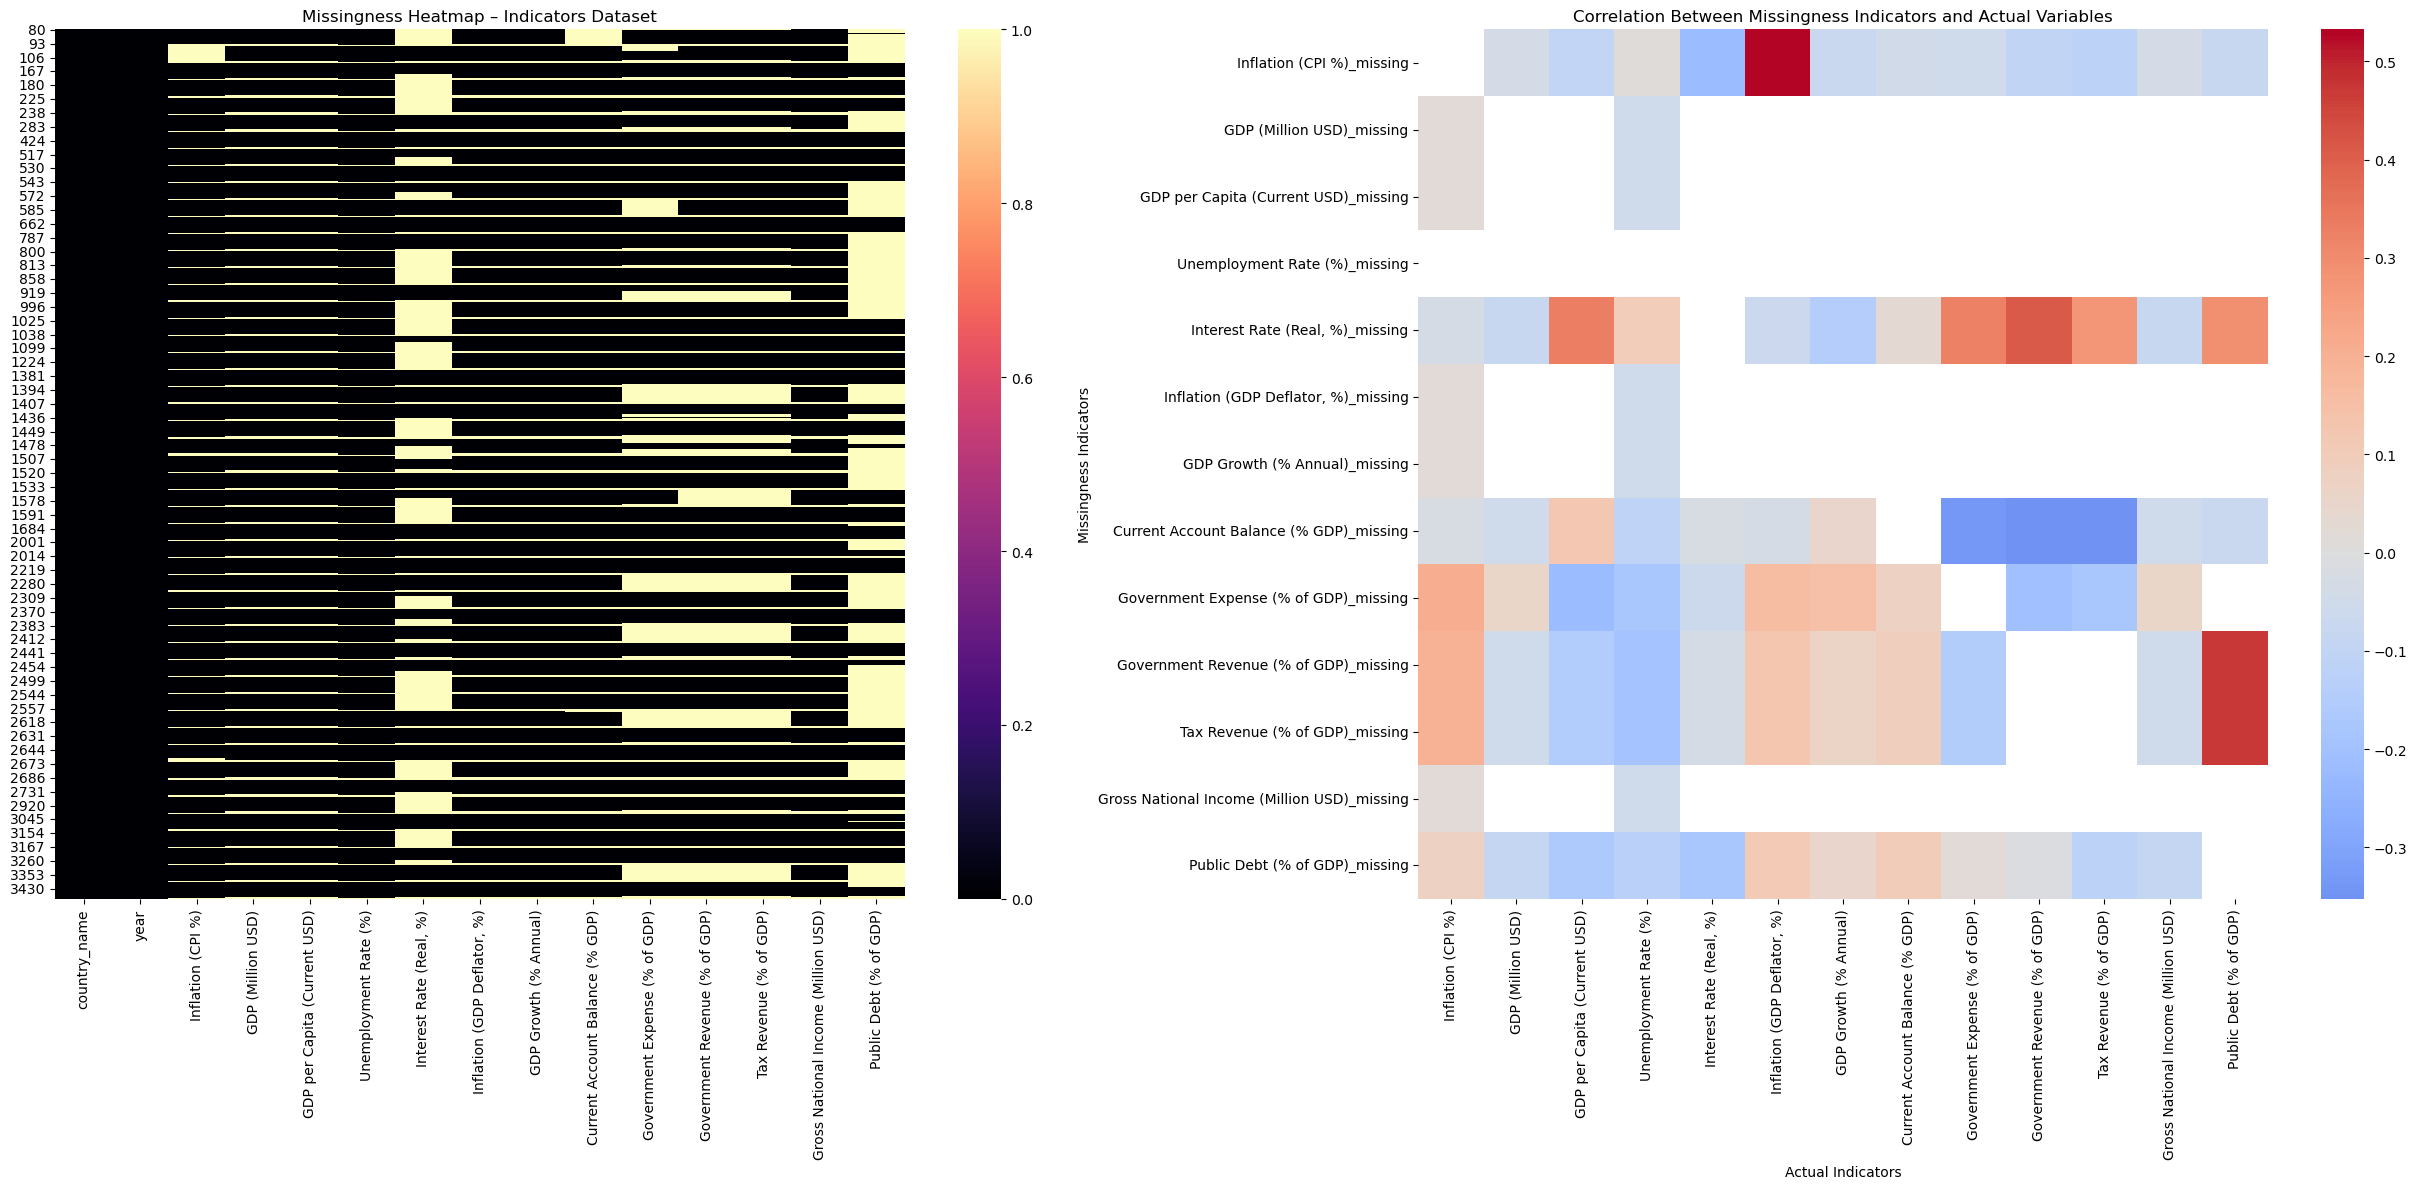

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(25, 12))

# ---------------------------------------------------------
# (1) Missingness heatmap
# ---------------------------------------------------------
sns.heatmap(indicators_df.isna(), cmap='magma', ax=axes[0])
axes[0].set_title('Missingness Heatmap – Indicators Dataset')

# ---------------------------------------------------------
# (2) Missingness Correlation
# ---------------------------------------------------------
# numeric columns only (exclude identifiers)
indicator_cols = [c for c in indicators_df.columns if c not in ['country_name', 'year']]

# Create missingness indicator DataFrame
missing_indicators = indicators_df[indicator_cols].isna().astype(int)
missing_indicators.columns = [f"{c}_missing" for c in indicator_cols]

# Combine actual + missingness data
combined = pd.concat([indicators_df[indicator_cols], missing_indicators], axis=1)

# Correlation matrix
corr = combined.corr()
corr_block = corr.loc[missing_indicators.columns, indicator_cols]

# Plot correlation heatmap
sns.heatmap(corr_block, cmap="coolwarm", center=0, annot=False, ax=axes[1])
axes[1].set_title("Correlation Between Missingness Indicators and Actual Variables")
axes[1].set_xlabel("Actual Indicators")
axes[1].set_ylabel("Missingness Indicators")

plt.tight_layout()

# ---------------------------------------------------------
# Save combined figure
# ---------------------------------------------------------
#plt.savefig('images/indicators_missingness.png', dpi=300, bbox_inches='tight')

plt.show()

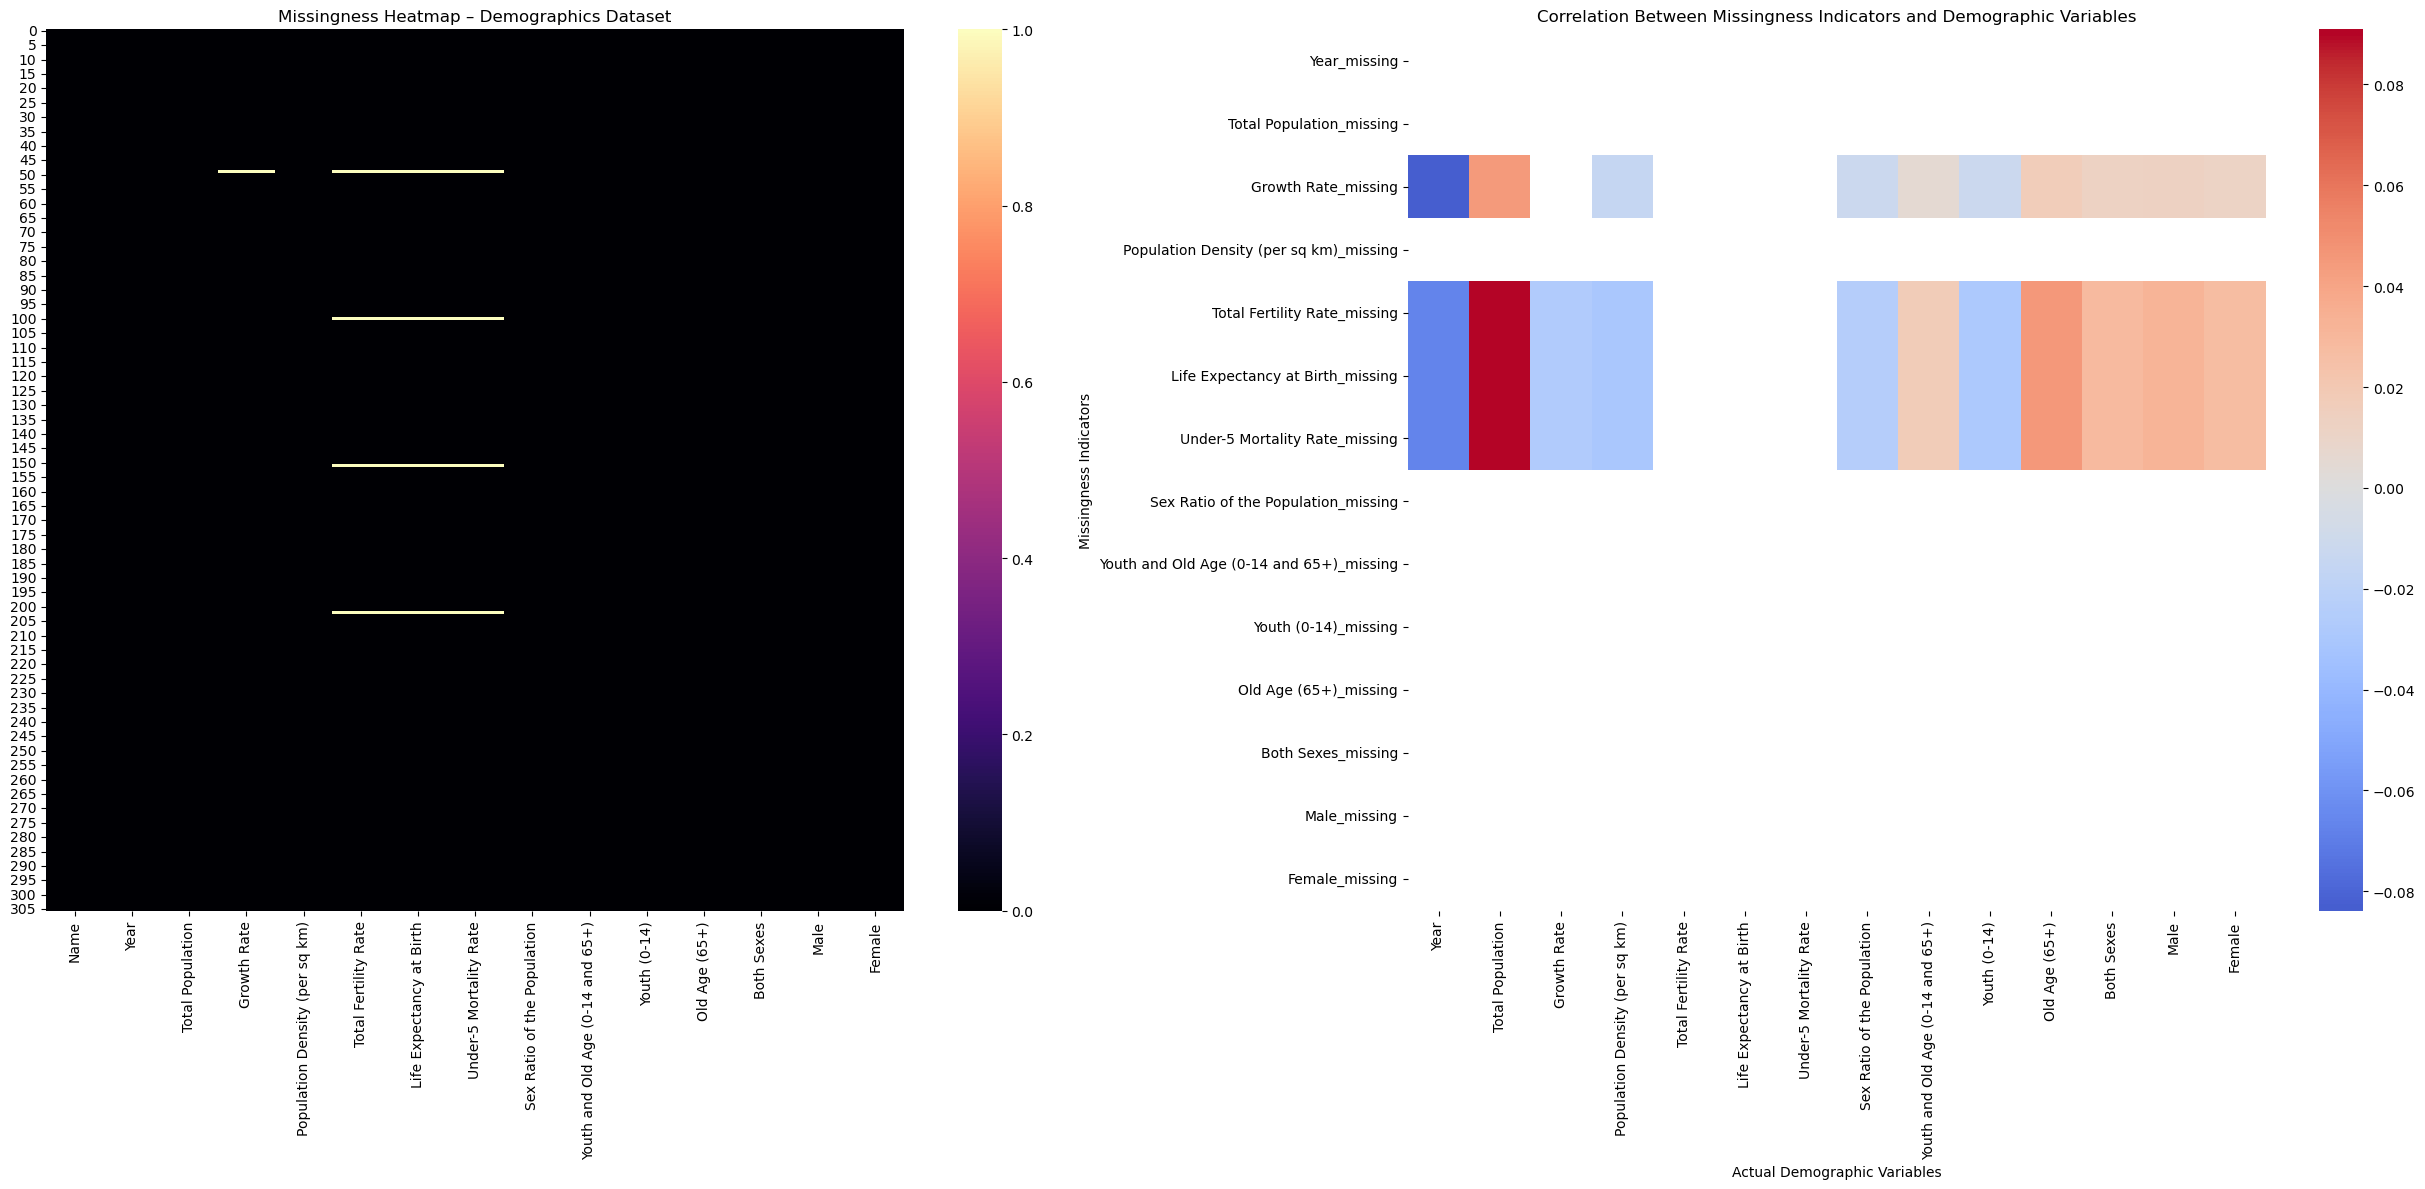

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(25, 12))

# ---------------------------------------------------------
# (1) Missingness Heatmap
# ---------------------------------------------------------
sns.heatmap(demographic_df.isna(), cmap='magma', ax=axes[0])
axes[0].set_title('Missingness Heatmap – Demographics Dataset')

# ---------------------------------------------------------
# (2) Missingness Correlation
# ---------------------------------------------------------

# numeric columns only (exclude identifiers)
demo_cols = [c for c in demographic_df.columns if c not in ['Name', 'year']]

# create missingness indicator DataFrame
missing_indicators_demo = demographic_df[demo_cols].isna().astype(int)
missing_indicators_demo.columns = [f"{c}_missing" for c in demo_cols]

# combine actual + missingness matrices
combined_demo = pd.concat([demographic_df[demo_cols], missing_indicators_demo], axis=1)

# full correlation matrix
corr_demo = combined_demo.corr()

# extract cross-block correlation
corr_block_demo = corr_demo.loc[missing_indicators_demo.columns, demo_cols]

# plot correlation heatmap
sns.heatmap(
    corr_block_demo, cmap="coolwarm", center=0, annot=False, ax=axes[1]
)
axes[1].set_title("Correlation Between Missingness Indicators and Demographic Variables")
axes[1].set_xlabel("Actual Demographic Variables")
axes[1].set_ylabel("Missingness Indicators")

plt.tight_layout()

# ---------------------------------------------------------
# Save combined figure
# ---------------------------------------------------------
#plt.savefig('images/demographics_missingness.png', dpi=300, bbox_inches='tight')

plt.show()

### Imputation Implementation

In [10]:
def stochastic_regression_imputation(df, value_cols, country_col, year_col):
    df_imputed = df.copy()

    for country in df[country_col].unique():
        subset = df[df[country_col] == country].sort_values(year_col)

        for col in value_cols:
            y = subset[col]
            x = subset[year_col].values.reshape(-1, 1)

            # Not enough data to fit a regression
            if y.notna().sum() < 2:
                continue

            # Fit regression
            model = LinearRegression().fit(x[y.notna()], y[y.notna()])
            preds = model.predict(x)

            # Add stochastic noise
            residual_std = np.std(y[y.notna()] - model.predict(x[y.notna()]))
            stochastic_preds = preds + np.random.normal(0, residual_std, size=len(preds))

            # Fill missing only
            filled = y.copy()
            filled[y.isna()] = stochastic_preds[y.isna()]
            df_imputed.loc[subset.index, col] = filled

    return df_imputed

def knn_imputation(df, value_cols, year_col, n_neighbors=5):
    df_knn = df.copy()
    imputer = KNNImputer(n_neighbors=n_neighbors)

    for year in df_knn[year_col].unique():
        year_mask = df_knn[year_col] == year
        df_year = df_knn.loc[year_mask, value_cols]

        # If all NaN, skip
        if df_year.isna().all().all():
            continue

        df_knn.loc[year_mask, value_cols] = imputer.fit_transform(df_year)

    return df_knn


In [11]:
# ---- Indicators Dataset Imputation ---- #

# define dataset columns
indicator_val_cols = [col for col in indicators_df.columns if col not in ['country_name', 'year']]

# Step 1: Stochastic regression
indicators_df_imputed_step1 = stochastic_regression_imputation(
    indicators_df, indicator_val_cols, country_col='country_name', year_col='year'
)

# Step 2: KNN imputation
indicators_df_imputed = knn_imputation(
    indicators_df_imputed_step1, indicator_val_cols, year_col='year'
)

In [12]:
# ---- Demographics Dataset Imputation ---- #

# define dataset columns
demographic_val_cols = [col for col in demographic_df.columns if col not in ['Name', 'Year']]

# Step 1: Stochastic regression
demographic_df_imputed_step1 = stochastic_regression_imputation(
    demographic_df, demographic_val_cols, country_col='Name', year_col='Year'
)

# Step 2: KNN imputation
demographic_df_imputed = knn_imputation(
    demographic_df_imputed_step1, demographic_val_cols, year_col='Year'
)

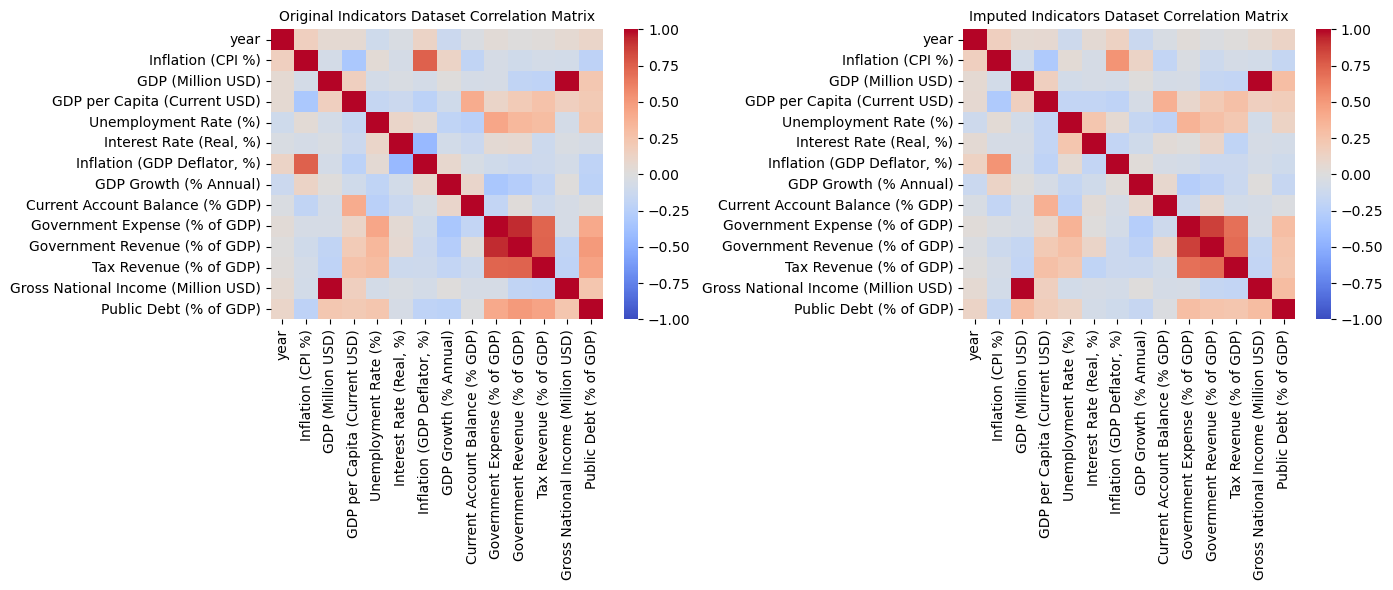

In [13]:
# ---- Indicators Dataset Imputation Analysis ----

numeric_cols = indicators_df.select_dtypes(include=['number']).columns

corr_orig = indicators_df[numeric_cols].corr()
corr_imputed = indicators_df_imputed[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr_orig, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, annot=False)
axes[0].set_title('Original Indicators Dataset Correlation Matrix', fontsize=10)

sns.heatmap(corr_imputed, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, annot=False)
axes[1].set_title('Imputed Indicators Dataset Correlation Matrix', fontsize=10)

plt.tight_layout()
#plt.savefig('images/indicators_correlation_structure_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

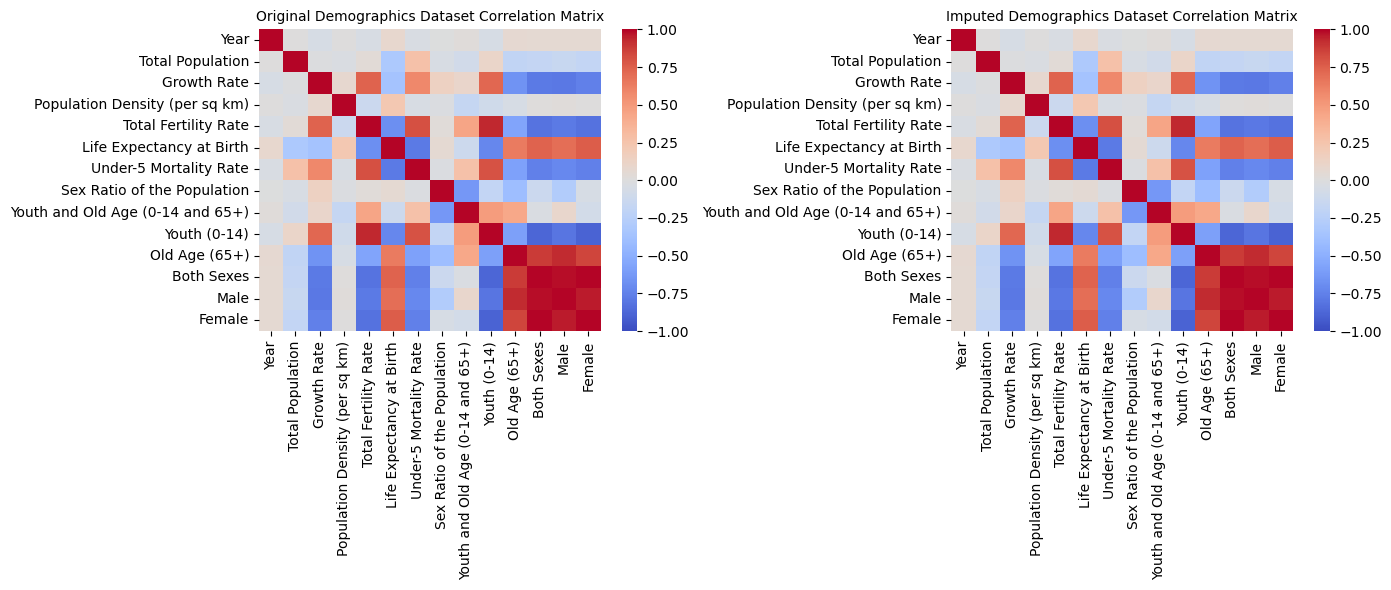

In [14]:
# ---- Demographic Dataset Imputation Analysis ----

numeric_cols = demographic_df.select_dtypes(include=['number']).columns

corr_orig = demographic_df[numeric_cols].corr()
corr_imputed = demographic_df_imputed[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr_orig, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, annot=False)
axes[0].set_title('Original Demographics Dataset Correlation Matrix', fontsize=10)

sns.heatmap(corr_imputed, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, annot=False)
axes[1].set_title('Imputed Demographics Dataset Correlation Matrix', fontsize=10)

plt.tight_layout()
#plt.savefig('images/demographics_correlation_structure_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Saving Cleaned and Preprocessed Datasets

In [15]:
# ---- Final Cleaning Steps ----

# filter indicators dataset for only years 2020-2025 to match disasters dataset
indicators_df_imputed = indicators_df_imputed[indicators_df_imputed['year'] >= 2020]

# saving cleaned datasets
#disaster_df.to_csv('datasets/disaster_df.csv', index=False)
#indicators_df_imputed.to_csv('datasets/indicators_df_imputed.csv', index=False)
#demographic_df_imputed.to_csv('datasets/demographic_df_imputed.csv', index=False)